In [17]:
from openpiv import tools, pyprocess, validation, filters, scaling

import numpy as np
import matplotlib.pyplot as plt
import cv2
%matplotlib inline

import imageio
import importlib_resources
import pathlib

In [18]:
frame_a = cv2.imread('piv_tests/2image_00.tif', cv2.IMREAD_GRAYSCALE)
frame_b = cv2.imread('piv_tests/2image_01.tif', cv2.IMREAD_GRAYSCALE)

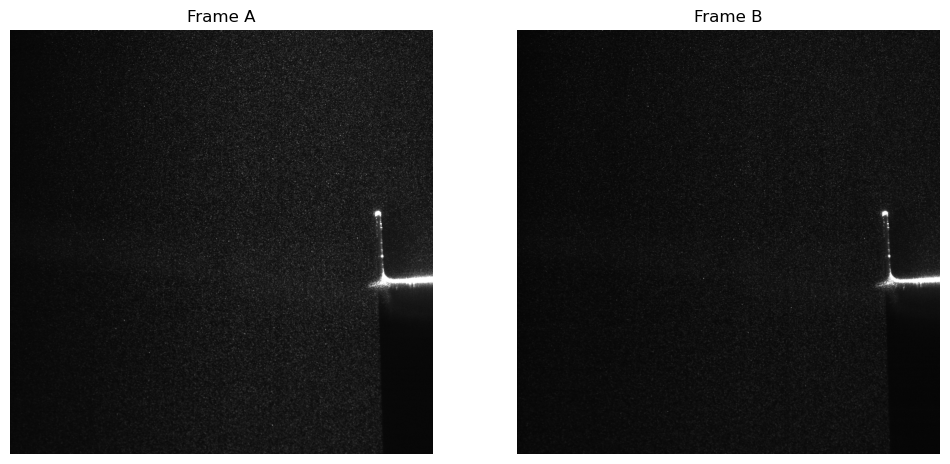

In [19]:
# Display the two frames
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(frame_a, cmap='gray')
axes[0].set_title('Frame A')
axes[0].set_axis_off()
axes[1].imshow(frame_b, cmap='gray')
axes[1].set_title('Frame B')
axes[1].set_axis_off()
plt.show()

## Run PIV

In [20]:
winsize = 32 # pixels, interrogation window size in frame A
searchsize = 38  # pixels, search area size in frame B
overlap = 17 # pixels, 50% overlap
dt = 0.02 # sec, time interval between the two frames

u0, v0, sig2noise = pyprocess.extended_search_area_piv(
    frame_a.astype(np.int32),
    frame_b.astype(np.int32),
    window_size=winsize,
    overlap=overlap,
    dt=dt,
    search_area_size=searchsize,
    sig2noise_method='peak2peak',
)

x, y = pyprocess.get_coordinates(
    image_size=frame_a.shape,
    search_area_size=searchsize,
    overlap=overlap,
)

## Post-process

In [21]:
# invalid_mask = validation.sig2noise_val(
#     sig2noise,
#     threshold = 1.05,
# )

# u2, v2 = filters.replace_outliers(
#     u0, v0,
#     invalid_mask,
#     method='localmean',
#     max_iter=3,
#     kernel_size=3,
# )
u2, v2 = u0, v0

# convert x,y to mm
# convert u,v to mm/sec

x, y, u3, v3 = scaling.uniform(
    x, y, u2, v2,
    scaling_factor = 96.52,  # 96.52 pixels/millimeter
)

# 0,0 shall be bottom left, positive rotation rate is counterclockwise
x, y, u3, v3 = tools.transform_coordinates(x, y, u3, v3)

In [22]:
print(np.shape(x))
print(np.shape(u3))

(47, 47)
(47, 47)


In [15]:
tools.save('exp1_001.txt' , x, y, u3, v3)


TypeError: save() missing 1 required positional argument: 'filename'

## Visualize

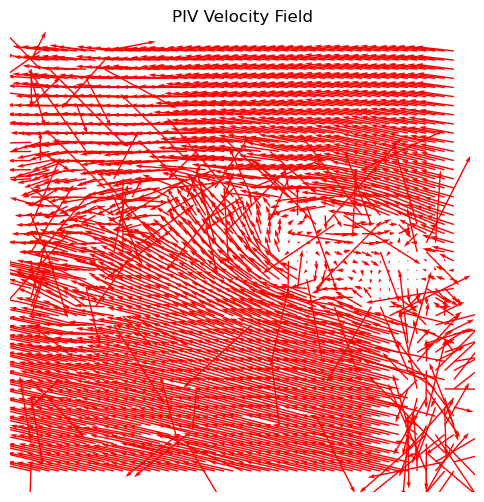

In [16]:
# Display the vector field on top of the original image
fig, ax = plt.subplots(figsize=(6, 6))
# ax.imshow(frame_a, cmap='gray')
ax.quiver(x, y, u3, v3, color='red', scale=50, width=0.003)
ax.set_title('PIV Velocity Field')
ax.set_axis_off()
plt.show()